# MOLIERE v1.0

**Title:** A Method Of Lines Integrator for Emissions Research and Exploration (MOLIERE) v 1.0  
**LLNL release:** LLNL-CODE-2017385  
**CP number:** CP 2025-187  
**Author:** Steven A. Hawks  
**License:** MIT (`SPDX-License-Identifier: MIT`)

In [1]:
# SPDX-License-Identifier: MIT
# Copyright (c) 2026, Lawrence Livermore National Security, LLC
# LLNL-CODE-2017385
# CP 2025-187
# Author: Steven A. Hawks

import numpy as np
import matplotlib.pyplot as plt
import time


In [2]:
from scipy.integrate import solve_ivp, simpson
from scipy.sparse import lil_matrix, csc_matrix, coo_matrix

# ============================================================================
# Vectorized helper functions (scalars AND arrays)
# ============================================================================

def temperature_vec(t, dt1, T0, T_target, RR):
    """Vectorized temperature profile -> (T_celsius, dTdt)."""
    t = np.asarray(t, dtype=float)
    scalar = t.ndim == 0
    t = np.atleast_1d(t)
    T = np.empty_like(t)
    dTdt = np.zeros_like(t)

    delta_T = T_target - T0
    if np.isclose(delta_T, 0.0):
        T.fill(T0)
    else:
        if RR == 0:
            raise ValueError('RR must be nonzero when T0 and Tfinal differ.')
        RR_eff = np.sign(delta_T) * abs(RR)
        t_ramp_end = dt1 + abs(delta_T) / abs(RR)
        m1 = t <= dt1
        m3 = t > t_ramp_end
        m2 = ~m1 & ~m3
        T[m1] = T0
        T[m2] = T0 + RR_eff * (t[m2] - dt1)
        dTdt[m2] = RR_eff
        T[m3] = T_target

    if scalar:
        return float(T[0]), float(dTdt[0])
    return T, dTdt


def flow_rate_vec(t, tEq, tFlush, Q_val):
    """Vectorized flow rate → Q array."""
    t = np.asarray(t, dtype=float)
    scalar = t.ndim == 0
    t = np.atleast_1d(t)
    Q = np.where(t % (tEq + tFlush) < tEq, 0.0, Q_val)
    return float(Q[0]) if scalar else Q


def feed_conc_vec(t, n_steps, delta, step_time, base_conc,
                  hold_time_initial, hold_time_final):
    """Vectorized feed concentration → ppbv array."""
    t = np.asarray(t, dtype=float)
    scalar = t.ndim == 0
    t = np.atleast_1d(t)
    total_time = hold_time_initial + 2 * n_steps * step_time + hold_time_final
    t_cycle = t % total_time
    result = np.full_like(t, base_conc)
    active = (t_cycle >= hold_time_initial) & (t_cycle < total_time - hold_time_final)
    if np.any(active):
        t_act = t_cycle[active] - hold_time_initial
        cs = (t_act / step_time).astype(int)
        rising = cs < n_steps
        result[active] = np.where(rising, base_conc + (cs + 1) * delta,
                                  base_conc + (2 * n_steps - cs - 1) * delta)
    return float(result[0]) if scalar else result




def _extract_temp_profile(params):
    """Return a normalized temperature profile tuple."""
    if 'Tfinal' in params:
        T_target = params['Tfinal']
    elif 'Tmax' in params:
        T_target = params['Tmax']
    else:
        raise KeyError("temp_params must define 'Tfinal' (preferred) or 'Tmax'.")
    return params['dt1'], params['T0'], T_target, params['RR']


def normalize_temp_params(params):
    """Return a copy of temp_params with both Tfinal and Tmax populated."""
    dt1, T0, T_target, RR = _extract_temp_profile(params)
    return {
        'dt1': dt1,
        'T0': T0,
        'Tfinal': T_target,
        'Tmax': T_target,
        'RR': RR,
    }


def validate_inputs(tfinal, temp_params, flow_params, cfeed_params,
                    m, R, mSample, rhoSample, Vvessel,
                    src_params, cD, F, cgas_init, N):
    """Validate user inputs and return a normalized src_params array."""
    src_params = np.asarray(src_params, dtype=float)

    if int(N) != N or N < 3:
        raise ValueError('N must be an integer >= 3.')
    if tfinal <= 0:
        raise ValueError('tfinal must be positive.')
    if R <= 0:
        raise ValueError('R must be positive.')
    if mSample <= 0 or rhoSample <= 0:
        raise ValueError('mSample and rhoSample must be positive.')
    if Vvessel <= mSample * 1e-3 / rhoSample:
        raise ValueError('Vvessel must be larger than the sample volume.')
    if src_params.size % 3 != 0:
        raise ValueError('src_params must contain groups of three values: c0, A, Ea.')
    if not np.isinf(cD) and cD <= 0:
        raise ValueError('cD must be positive or np.inf.')
    if not np.isinf(F) and F < 0:
        raise ValueError('F must be non-negative or np.inf.')
    if cgas_init < 0:
        raise ValueError('cgas_init must be non-negative.')
    if m not in (0, 1, 2):
        raise ValueError('m must be 0 (slab), 1 (cylinder), or 2 (sphere).')

    dt1, T0, T_target, RR = _extract_temp_profile(temp_params)
    if RR == 0 and not np.isclose(T_target, T0):
        raise ValueError('RR must be nonzero when T0 and Tfinal differ.')
    if flow_params['tEq'] + flow_params['tFlush'] <= 0:
        raise ValueError('tEq + tFlush must be positive.')

    n_steps = cfeed_params['n_steps']
    if int(n_steps) != n_steps or n_steps < 0:
        raise ValueError('n_steps must be a non-negative integer.')
    if n_steps > 0 and cfeed_params['step_time'] <= 0:
        raise ValueError('step_time must be positive when n_steps > 0.')
    total_feed_time = (
        cfeed_params['hold_time_initial']
        + 2 * int(n_steps) * cfeed_params['step_time']
        + cfeed_params['hold_time_final']
    )
    if total_feed_time <= 0:
        raise ValueError('The total feed profile duration must be positive.')

    return src_params


# ============================================================================
# Sparse Jacobian sparsity pattern
# ============================================================================

def generate_jacobian_sparsity(N, num_srcs, is_inf_F):
    """Build Jacobian sparsity as sparse CSC matrix."""
    total = N + num_srcs if is_inf_F else N + 1 + num_srcs
    sp = lil_matrix((total, total), dtype=np.int8)
    for i in range(N):
        sp[i, i] = 1
    for i in range(1, N - 1):
        sp[i, i - 1] = 1
        sp[i, i + 1] = 1
    if N > 1:
        sp[0, 1] = 1
    if is_inf_F:
        if N - 1 >= 1: sp[N - 1, N - 2] = 1
        if N - 1 >= 2: sp[N - 1, N - 3] = 1
        for si in range(num_srcs):
            sp[N + si, N + si] = 1
            sp[:N - 1, N + si] = 1
    else:
        if N - 1 >= 1: sp[N - 1, N - 2] = 1
        sp[N - 1, N] = 1
        sp[N, N - 1] = 1
        sp[N, N] = 1
        for si in range(num_srcs):
            row = N + 1 + si
            sp[row, row] = 1
            sp[:N, row] = 1
    return csc_matrix(sp)


# ============================================================================
# ODE factory: builds a specialized RHS + optional analytical Jacobian
# ============================================================================

def make_ode_system(N, x, R, h, cD, beta, dt1, T0, Tmax, RR, tEq, tFlush, Q_val,
                    n_steps, delta, step_time, base_conc, hold_time_initial,
                    hold_time_final, src_params, Vheadspace, F, Rgas, D0, EaD, K0, EaK, m_geom):
    """
    Return (rhs_func, jac_func_or_sparsity).
    For constant-D cases (isinf(cD)), returns an analytical Jacobian.
    For concentration-dependent D, returns a sparsity pattern for numerical Jacobian.
    """
    num_srcs = len(src_params) // 3
    is_inf_F = np.isinf(F)
    is_inf_cD = np.isinf(cD)

    # Pre-compute invariants
    h2 = h * h
    inv_h2 = 1.0 / h2
    inv_2h = 1.0 / (2.0 * h)
    mp1 = m_geom + 1
    inv_R_beta = 1.0 / (R * beta)
    inv_Vhs = 1.0 / Vheadspace
    neg_EaD_Rgas = -EaD / Rgas
    EaK_Rgas = EaK / Rgas
    delta_T = Tmax - T0
    if np.isclose(delta_T, 0.0):
        RR_eff = 0.0
        t_ramp_end = dt1
    else:
        RR_eff = np.sign(delta_T) * abs(RR)
        t_ramp_end = dt1 + abs(delta_T) / abs(RR)
    period = tEq + tFlush
    total_feed_time = hold_time_initial + 2 * n_steps * step_time + hold_time_final
    inv_cD = 0.0 if is_inf_cD else 1.0 / cD
    x_int = x[1:-1].copy()
    m_over_x_int = m_geom / x_int if m_geom != 0 else np.zeros(N - 2)

    if num_srcs > 0:
        src_A = src_params[1::3].copy()
        src_Ea = src_params[2::3].copy()
    else:
        src_A = np.empty(0)
        src_Ea = np.empty(0)

    n_total = (N + num_srcs) if is_inf_F else (N + 1 + num_srcs)

    # ---- Inline scalar helpers (no dict lookups, no function call overhead) ----
    def _temp(t):
        if t <= dt1:
            return T0, 0.0
        if t <= t_ramp_end:
            return T0 + RR_eff * (t - dt1), RR_eff
        return Tmax, 0.0

    def _flow(t):
        return 0.0 if (t % period) < tEq else Q_val

    def _feed(t):
        if n_steps == 0: return base_conc
        tc = t % total_feed_time
        if tc < hold_time_initial or tc >= total_feed_time - hold_time_final:
            return base_conc
        cs = int((tc - hold_time_initial) / step_time)
        return base_conc + (cs + 1) * delta if cs < n_steps else base_conc + (2 * n_steps - cs - 1) * delta

    # ==================================================================
    # CASE 1: isinf(F) and isinf(cD)  —  most common case
    # ==================================================================
    if is_inf_F and is_inf_cD:
        # Boundary source offset
        src_off = N

        def rhs(t, c):
            TC, dTdt_val = _temp(t)
            T = TC + 273.15
            inv_T = 1.0 / T
            Q = _flow(t)
            cfeed = _feed(t) * 0.001 / 22.414 * 273.15 * inv_T

            K = K0 * np.exp(EaK_Rgas * inv_T)
            dKdT_K = -EaK_Rgas * dTdt_val * inv_T * inv_T
            D = D0 * np.exp(neg_EaD_Rgas * inv_T)

            cs = c[:N]

            # Source contribution (scalar sum to add to interior nodes)
            src_total = 0.0
            if num_srcs > 0:
                exp_ea = np.exp(-src_Ea / (Rgas * T))
                rates = src_A * exp_ea * c[src_off:src_off + num_srcs]
                src_total = float(np.sum(rates))

            dcdt = np.empty(n_total)

            # Interior (vectorized)
            dcdx = (cs[2:] - cs[:-2]) * inv_2h
            d2cdx2 = (cs[2:] - 2.0 * cs[1:-1] + cs[:-2]) * inv_h2
            dcdt[1:N - 1] = D * (d2cdx2 + m_over_x_int * dcdx) + src_total

            # Center (symmetry BC)
            dcdt[0] = 2.0 * D * mp1 * (cs[1] - cs[0]) * inv_h2 + src_total

            # Boundary (equilibrium gas)
            dcRdx = (3.0 * cs[-1] - 4.0 * cs[-2] + cs[-3]) * inv_2h
            dcdt[N - 1] = (-mp1 * K * D * dcRdx * inv_R_beta
                           - cs[-1] * (Q * inv_Vhs - dKdT_K)
                           + Q * K * cfeed * inv_Vhs)

            # Source decay
            if num_srcs > 0:
                dcdt[src_off:src_off + num_srcs] = -rates

            return dcdt

        # ---- Analytical Jacobian ----
        # Pre-build COO index arrays (fixed structure, only values change)
        # Interior tridiagonal: 3*(N-2) entries
        idx_int = np.arange(1, N - 1)
        # Center: 2 entries (row 0, cols 0 and 1)
        # Boundary: 3 entries (row N-1, cols N-3, N-2, N-1)
        # Source self-decay: num_srcs entries
        # Source → interior coupling: (N-1) * num_srcs entries

        jac_rows = np.concatenate([
            [0, 0],                                          # center
            idx_int, idx_int, idx_int,                        # interior sub/diag/super
            [N - 1, N - 1, N - 1],                           # boundary
            np.arange(src_off, src_off + num_srcs),          # source self
            np.tile(np.arange(N - 1), num_srcs),             # source → interior
        ]).astype(np.int32)

        jac_cols = np.concatenate([
            [0, 1],                                          # center
            idx_int - 1, idx_int, idx_int + 1,                # interior sub/diag/super
            [N - 3, N - 2, N - 1],                           # boundary
            np.arange(src_off, src_off + num_srcs),          # source self
            np.repeat(np.arange(src_off, src_off + num_srcs), N - 1),
        ]).astype(np.int32)

        n_entries = len(jac_rows)
        _jac_vals = np.empty(n_entries)

        def jac(t, c):
            TC, dTdt_val = _temp(t)
            T = TC + 273.15
            inv_T = 1.0 / T
            Q = _flow(t)

            K = K0 * np.exp(EaK_Rgas * inv_T)
            dKdT_K = -EaK_Rgas * dTdt_val * inv_T * inv_T
            D = D0 * np.exp(neg_EaD_Rgas * inv_T)

            vals = _jac_vals

            # Center node: ∂f₀/∂c₀, ∂f₀/∂c₁
            v = 2.0 * D * mp1 * inv_h2
            vals[0] = -v
            vals[1] = v

            # Interior nodes: sub-diagonal, diagonal, super-diagonal
            base = 2
            n_int = N - 2
            vals[base:base + n_int] = D * (inv_h2 - m_over_x_int * inv_2h)           # sub
            vals[base + n_int:base + 2 * n_int] = D * (-2.0 * inv_h2)                 # diag
            vals[base + 2 * n_int:base + 3 * n_int] = D * (inv_h2 + m_over_x_int * inv_2h)  # super

            # Boundary node
            base_bnd = base + 3 * n_int
            coeff = -mp1 * K * D * inv_R_beta
            vals[base_bnd] = coeff * inv_2h                                   # ∂/∂c_{N-3}
            vals[base_bnd + 1] = coeff * (-4.0 * inv_2h)                     # ∂/∂c_{N-2}
            vals[base_bnd + 2] = coeff * (3.0 * inv_2h) - (Q * inv_Vhs - dKdT_K)  # ∂/∂c_{N-1}

            # Source terms
            base_src = base_bnd + 3
            if num_srcs > 0:
                k_src = src_A * np.exp(-src_Ea / (Rgas * T))
                vals[base_src:base_src + num_srcs] = -k_src           # self-decay
                # Source → interior coupling
                base_coup = base_src + num_srcs
                for si in range(num_srcs):
                    vals[base_coup + si * (N - 1):base_coup + (si + 1) * (N - 1)] = k_src[si]

            return csc_matrix(coo_matrix(
                (vals.copy(), (jac_rows, jac_cols)), shape=(n_total, n_total)))

        return rhs, dict(jac=jac)

    # ==================================================================
    # CASE 2: isinf(F) and NOT isinf(cD)
    # ==================================================================
    elif is_inf_F and not is_inf_cD:
        src_off = N

        def rhs(t, c):
            TC, dTdt_val = _temp(t)
            T = TC + 273.15
            inv_T = 1.0 / T
            Q = _flow(t)
            cfeed = _feed(t) * 0.001 / 22.414 * 273.15 * inv_T

            K = K0 * np.exp(EaK_Rgas * inv_T)
            dKdT_K = -EaK_Rgas * dTdt_val * inv_T * inv_T
            cs = c[:N]

            D = D0 * np.exp(cs * inv_cD + neg_EaD_Rgas * inv_T)
            dDdc = D * inv_cD

            src_total = 0.0
            if num_srcs > 0:
                rates = src_A * np.exp(-src_Ea / (Rgas * T)) * c[src_off:src_off + num_srcs]
                src_total = float(np.sum(rates))

            dcdt = np.empty(n_total)
            dcdx = (cs[2:] - cs[:-2]) * inv_2h
            d2cdx2 = (cs[2:] - 2.0 * cs[1:-1] + cs[:-2]) * inv_h2

            dcdt[1:N - 1] = (dDdc[1:-1] * dcdx ** 2
                             + D[1:-1] * (d2cdx2 + m_over_x_int * dcdx) + src_total)
            dcdt[0] = 2.0 * D[0] * mp1 * (cs[1] - cs[0]) * inv_h2 + src_total

            dcRdx = (3.0 * cs[-1] - 4.0 * cs[-2] + cs[-3]) * inv_2h
            dcdt[N - 1] = (-mp1 * K * D[-1] * dcRdx * inv_R_beta
                           - cs[-1] * (Q * inv_Vhs - dKdT_K)
                           + Q * K * cfeed * inv_Vhs)

            if num_srcs > 0:
                dcdt[src_off:src_off + num_srcs] = -rates
            return dcdt

        # Fall back to numerical Jacobian with sparsity for c-dependent D
        sparsity = generate_jacobian_sparsity(N, num_srcs, True)
        return rhs, dict(jac_sparsity=sparsity)

    # ==================================================================
    # CASE 3: NOT isinf(F) and isinf(cD)
    # ==================================================================
    elif not is_inf_F and is_inf_cD:
        src_off = N + 1

        def rhs(t, c):
            TC, _ = _temp(t)
            T = TC + 273.15
            inv_T = 1.0 / T
            Q = _flow(t)
            cfeed = _feed(t) * 0.001 / 22.414 * 273.15 * inv_T

            K = K0 * np.exp(EaK_Rgas * inv_T)
            D = D0 * np.exp(neg_EaD_Rgas * inv_T)

            cs = c[:N]
            cR = c[N - 1]
            c_gas = c[N]

            src_total = 0.0
            if num_srcs > 0:
                rates = src_A * np.exp(-src_Ea / (Rgas * T)) * c[src_off:src_off + num_srcs]
                src_total = float(np.sum(rates))

            dcdt = np.empty(n_total)
            dcdx = (cs[2:] - cs[:-2]) * inv_2h
            d2cdx2 = (cs[2:] - 2.0 * cs[1:-1] + cs[:-2]) * inv_h2

            dcdt[1:N - 1] = D * (d2cdx2 + m_over_x_int * dcdx) + src_total
            dcdt[0] = 2.0 * D * mp1 * (cs[1] - cs[0]) * inv_h2 + src_total

            dcdx_R = 60.0 * F * (c_gas * K - cR) / D
            d2cdx2_R = 2.0 * (h * dcdx_R + cs[N - 2] - cR) * inv_h2
            dcdt[N - 1] = D * (d2cdx2_R + m_geom * dcdx_R / R) + src_total
            dcdt[N] = (mp1 * 60.0 * F * (cR - c_gas * K) / (beta * R)
                       + Q * inv_Vhs * (cfeed - c_gas))

            if num_srcs > 0:
                dcdt[src_off:src_off + num_srcs] = -rates
            return dcdt

        sparsity = generate_jacobian_sparsity(N, num_srcs, False)
        return rhs, dict(jac_sparsity=sparsity)

    # ==================================================================
    # CASE 4: NOT isinf(F) and NOT isinf(cD)
    # ==================================================================
    else:
        src_off = N + 1

        def rhs(t, c):
            TC, _ = _temp(t)
            T = TC + 273.15
            inv_T = 1.0 / T
            Q = _flow(t)
            cfeed = _feed(t) * 0.001 / 22.414 * 273.15 * inv_T

            K = K0 * np.exp(EaK_Rgas * inv_T)
            cs = c[:N]
            cR = c[N - 1]
            c_gas = c[N]

            D = D0 * np.exp(cs * inv_cD + neg_EaD_Rgas * inv_T)
            dDdc = D * inv_cD

            src_total = 0.0
            if num_srcs > 0:
                rates = src_A * np.exp(-src_Ea / (Rgas * T)) * c[src_off:src_off + num_srcs]
                src_total = float(np.sum(rates))

            dcdt = np.empty(n_total)
            dcdx = (cs[2:] - cs[:-2]) * inv_2h
            d2cdx2 = (cs[2:] - 2.0 * cs[1:-1] + cs[:-2]) * inv_h2

            dcdt[1:N - 1] = (dDdc[1:-1] * dcdx ** 2
                             + D[1:-1] * (d2cdx2 + m_over_x_int * dcdx) + src_total)
            dcdt[0] = 2.0 * D[0] * mp1 * (cs[1] - cs[0]) * inv_h2 + src_total

            dcdx_R = 60.0 * F * (c_gas * K - cR) / D[-1]
            d2cdx2_R = 2.0 * (h * dcdx_R + cs[N - 2] - cR) * inv_h2
            dcdt[N - 1] = (dDdc[-1] * dcdx_R ** 2
                           + D[-1] * (d2cdx2_R + m_geom * dcdx_R / R) + src_total)
            dcdt[N] = (mp1 * 60.0 * F * (cR - c_gas * K) / (beta * R)
                       + Q * inv_Vhs * (cfeed - c_gas))

            if num_srcs > 0:
                dcdt[src_off:src_off + num_srcs] = -rates
            return dcdt

        sparsity = generate_jacobian_sparsity(N, num_srcs, False)
        return rhs, dict(jac_sparsity=sparsity)


# ============================================================================
# Main simulation
# ============================================================================

def run_simulation(tfinal, temp_params, flow_params, cfeed_params,
                   m, R, mSample, rhoSample, Vvessel, MW_analyte,
                   src_params, EaK, K50, D50, EaD, cD, F, c0free, cgas_init, N):
    """Run diffusion simulation with the given parameters."""
    src_params = validate_inputs(
        tfinal, temp_params, flow_params, cfeed_params,
        m, R, mSample, rhoSample, Vvessel,
        src_params, cD, F, cgas_init, N,
    )
    temp_params = normalize_temp_params(temp_params)
    num_srcs = len(src_params) // 3
    is_inf_F = np.isinf(F)
    vSample = mSample * 1E-3 / rhoSample
    Vheadspace = Vvessel - vSample
    beta = Vheadspace / vSample
    Rgas = 8.31446261815324 / 1000
    K0 = K50 * np.exp(-EaK / Rgas / (50 + 273.15))
    D0 = 60 * D50 * np.exp(EaD / Rgas / (50 + 273.15))

    x = np.linspace(0, R, N)
    h = x[1] - x[0]
    K_t0 = K0 * np.exp(EaK / Rgas / (temp_params['T0'] + 273.15))

    # Initial conditions
    c_init = np.full(N, c0free)
    if is_inf_F:
        c_init[-1] = cgas_init * K_t0
        ic = np.hstack((c_init, src_params[::3])) if num_srcs > 0 else c_init
    else:
        ic = np.hstack((c_init, [cgas_init], src_params[::3])) if num_srcs > 0 else np.hstack((c_init, [cgas_init]))

    # Extract params once
    dt1, T0, Tmax, RR = _extract_temp_profile(temp_params)
    tEq, tFlush, Q_val = flow_params['tEq'], flow_params['tFlush'], flow_params['Q']
    ns = cfeed_params['n_steps']
    dl = cfeed_params['delta']
    st = cfeed_params['step_time']
    bc = cfeed_params['base_conc']
    hti = cfeed_params['hold_time_initial']
    htf = cfeed_params['hold_time_final']

    # Build specialized ODE system
    rhs, solver_kw = make_ode_system(
        N, x, R, h, cD, beta, dt1, T0, Tmax, RR, tEq, tFlush, Q_val,
        ns, dl, st, bc, hti, htf, src_params, Vheadspace, F, Rgas, D0, EaD, K0, EaK, m)

    # Solve
    t0 = time.time()
    result = solve_ivp(rhs, [0, tfinal], ic, method='BDF',
                       rtol=1e-7, atol=1e-8, max_step=tfinal / 10, **solver_kw)
    elapsed = time.time() - t0
    print(f"Solve time: {elapsed:.4f} seconds")

    if not result.success:
        raise RuntimeError(f'solve_ivp failed: {result.message}')

    t = result.t
    y = result.y.T
    cR = y[:, N - 1]

    # ---- Vectorized post-processing ----
    T_C, _ = temperature_vec(t, dt1, T0, Tmax, RR)
    Q = flow_rate_vec(t, tEq, tFlush, Q_val)
    T_K = T_C + 273.15
    K = K0 * np.exp(EaK / Rgas / T_K)
    S = K * (273.15 / T_K)
    DR = D0 * np.exp(-EaD / Rgas / T_K + cR * (0.0 if np.isinf(cD) else 1.0 / cD))

    c_feed_ppbv = feed_conc_vec(t, ns, dl, st, bc, hti, htf)
    c_feed_uM = c_feed_ppbv / 1000 / 22.414 * 273.15 / T_K
    c_feed_ugm3 = c_feed_uM * 1000 * MW_analyte

    c_gas = cR / K if is_inf_F else y[:, N]
    cGas_ugm3 = c_gas * 1000 * MW_analyte
    cGasPPBV = c_gas * 1000 * 22.414 / 273.15 * T_K
    cGasPPBVEq = c0free / (K + beta) * 1000 * 22.414 / 273.15 * T_K

    # Simpson integrals (pre-multiply weights)
    xm = x ** m
    weighted = y[:, :N] * xm[np.newaxis, :]
    initial_integral = simpson(weighted[0], x=x)
    time_integrals = np.array([simpson(weighted[i], x=x) for i in range(len(t))])
    delta_mass_free = -(m + 1) / R ** (m + 1) * vSample * MW_analyte * (initial_integral - time_integrals)

    src_off = N if is_inf_F else N + 1
    if num_srcs > 0:
        delta_mass_src = -vSample * MW_analyte * sum(
            src_params[3 * j] - y[:, src_off + j] for j in range(num_srcs))
    else:
        delta_mass_src = np.zeros_like(t)

    delta_mass_total = delta_mass_free + delta_mass_src

    # Mass balance check
    c0_end = (m + 1) / R ** (m + 1) * simpson(weighted[-1], x=x)
    c_Gas_end = c_gas[-1] * beta
    initial_total = c0free + beta * cgas_init + float(np.sum(src_params[::3]))
    final_source_total = float(np.sum(y[-1, src_off:src_off + num_srcs])) if num_srcs > 0 else 0.0
    final_total = c0_end + c_Gas_end + final_source_total
    denom = initial_total - final_total

    if np.abs(denom) < 1E-3:
        print("Warning: denominator nearly zero. Using absolute error metric instead.")
        c0Chk = simpson(Q * (c_gas - c_feed_uM) / vSample, x=t)
        print(f'Mass Balance Error = {100 * c0Chk:.2g} %')
    else:
        c0Chk = simpson(Q * (c_gas - c_feed_uM) / vSample, x=t) / denom
        print(f'Mass Balance Error = {100 * (1 - c0Chk):.2g} %')

    return {
        't (min)': t,
        'c_gas (uM)': c_gas,
        'c_gas (ug/m^3)': cGas_ugm3,
        'c_gas (ppbv)': cGasPPBV,
        'T (C)': T_C,
        'Δm (ng)': delta_mass_total,
        'cGasEq (ppbv)': cGasPPBVEq,
        'Q (ml/min)': Q,
        'c_feed (uM)': c_feed_uM,
        'c_feed (ppbv)': c_feed_ppbv,
        'c_feed (ug/m^3)': c_feed_ugm3,
        'K': K,
        'S (cm^3 @ STP/atm/cm^3 sample)': S,
        'D @ R (cm^2/min)': DR,
    }


In [3]:
# SIMULATION PARAMETERS
tfinal = 150  # Final simulation time (min)
N = 201 # number of grid points

# Temperature Profile parameters
temp_params = {
    'dt1': 60,    # min (initial isothermal period)
    'T0': 50,       # °C, initial temperature
    'Tfinal': 250,    # °C, final temperature
    'RR': 5      # °C/min, ramp rate
}

# Flow parameters
flow_params = {
    'tEq': 30,         # min, time at which Q = 0
    'tFlush': tfinal, # min, flushing time (when Q becomes active)
    'Q': 20           # ml/min, flow rate
}

# Feed concentration profile parameters
cfeed_params = {
    'n_steps': 0,               # number of steps
    'delta': 1000,              # ppbv, concentration change per step
    'step_time': 240,           # min, time for each step
    'base_conc': 0,             # ppbv, base concentration
    'hold_time_initial': 60,    # min, initial hold time
    'hold_time_final': 3000     # min, final hold time
}

# Sample and vessel characteristics
m = 2               # 0 = slab, 1 = cylinder, 2 = sphere
R = 200e-4          # cm, sample radius
mSample = 50        # mg, mass of sample
rhoSample = 1       # g/ml, density of sample
Vvessel = 10        # ml, vessel volume
MW_analyte = 18.0   # g/mol, molecular weight of analyte

# Source parameters: empty array for no chemical sources
# src_params = np.array([]) # Empty = no sources
# Example with sources:
src_params = np.array([100, 1E8, 80])  # list of: c0 (uM), A (1/min), Ea (kJ/mol), c0 (uM),...etc.

# Other parameters
EaK = 35      # kJ/mol
K50 = 150     # K at 50 °C
D50 = 1E-7    # cm^2/s at 50 °C
EaD = 15      # kJ/mol
cD = np.inf      # uM, plasticizer power parameter
F = np.inf      # cm/s; use np.inf for infinite flow condition
c0free = 10  # uM, initial free concentration
cgas_init = 0 # uM, initial gas concentration

Solve time: 0.1135 seconds
Mass Balance Error = 7.6e-05 %


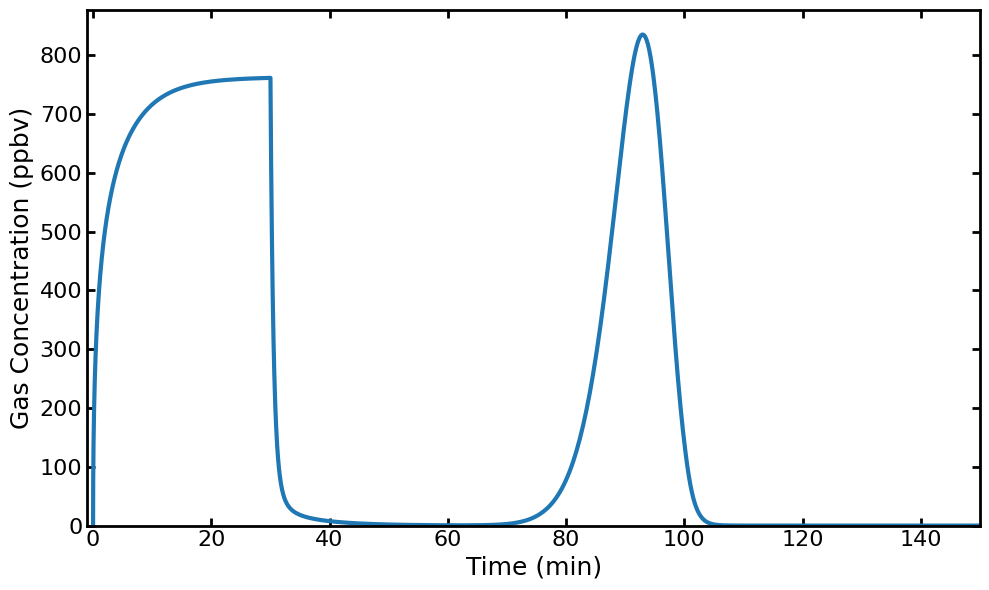

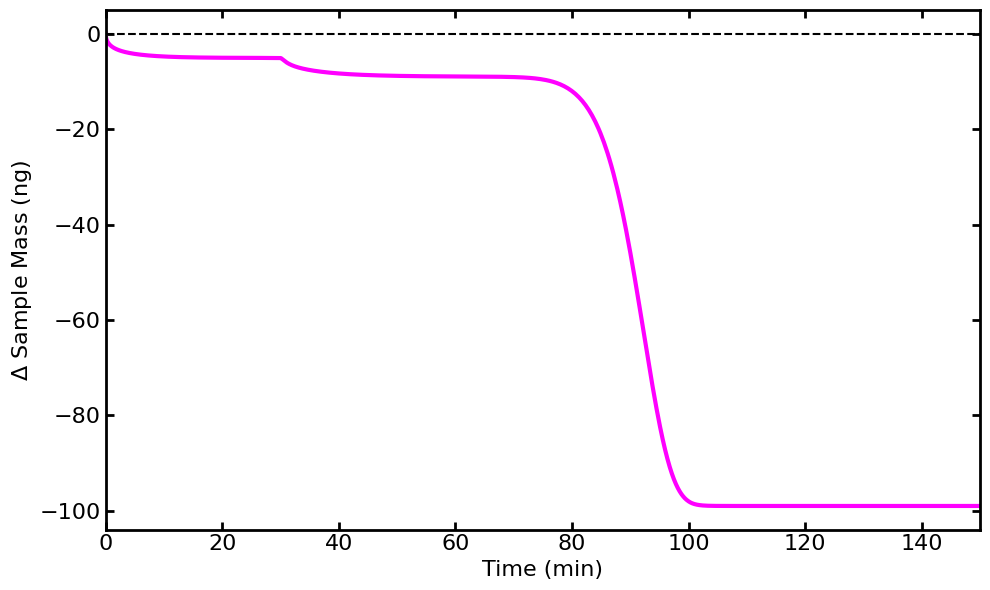

In [4]:
# Run the simulation
results = run_simulation(tfinal, temp_params, flow_params, cfeed_params,
                         m, R, mSample, rhoSample, Vvessel, MW_analyte,
                         src_params, EaK, K50, D50, EaD, cD, F, c0free, cgas_init, N)

# Plot gas concentration
plt.figure(figsize=(10, 6))
plt.plot(results['t (min)'], results['c_gas (ppbv)'], label='c_gas', linewidth=3)
plt.xlim([np.min(results['t (min)']), np.max(results['t (min)'])])
plt.xlabel('Time (min)', fontsize=18)
plt.ylabel('Gas Concentration (ppbv)', fontsize=18)
plt.tick_params(axis='both', which='major', top=True, right=True, labelsize=16,
                direction='in', length=6, width=2)
plt.tick_params(axis='y', which='minor', right=True, direction='in', length=4, width=1.5)
plt.xlim(left=-1)
plt.ylim(bottom=0)
ax = plt.gca()
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
plt.tight_layout()
plt.show()

# Plot sample mass change
plt.figure(figsize=(10, 6))
plt.plot(results['t (min)'], results['Δm (ng)'], 
         label='Sample mass change', linewidth=3, color='magenta')
plt.xlabel('Time (min)', fontsize=16)
plt.ylabel('$\\Delta$ Sample Mass (ng)', fontsize=16)
plt.xlim([np.min(results['t (min)']), np.max(results['t (min)'])])
plt.axhline(y=0, color='black', linestyle='--')
plt.tick_params(axis='both', which='major', top=True, right=True, labelsize=16,
                direction='in', length=6, width=2)
ax = plt.gca()
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
plt.tight_layout()
plt.show()
# Optional export: import pandas as pd; pd.DataFrame(results).to_clipboard(index=False)